I0000 00:00:1772220521.977894   94668 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772220522.001080   94668 cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1772220522.452574   94668 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


48000
1248000
Downsampling data by a factor of 1000...
(296, 1248000)
Downsampled array shape: (296, 1248)
Creating heatmap...


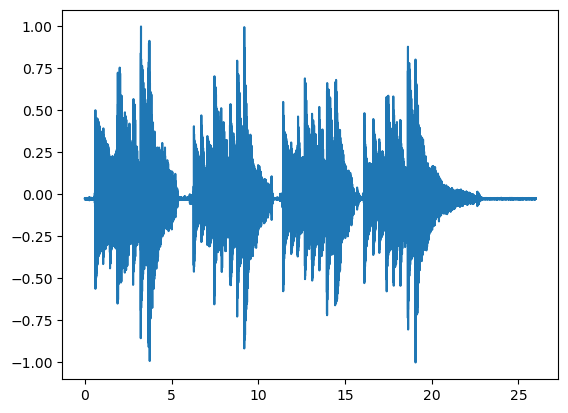

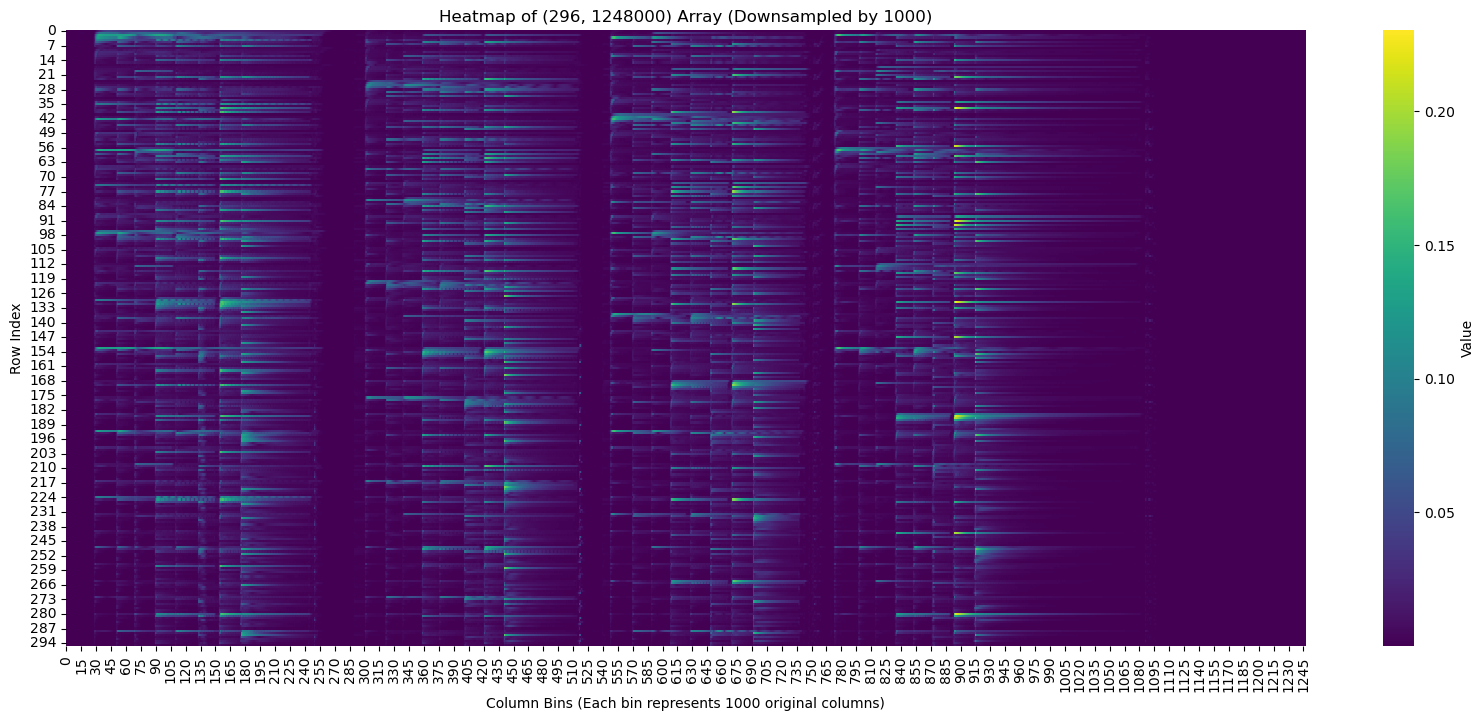

Heatmap displayed.
reshape data by a factor of 256...
(296, 1248000)
Reshaped the output data to  
(4875, 296, 256)
Downsampling data by a factor of 1...
(296, 4875)
Downsampled array shape: (296, 4875)
Creating heatmap...


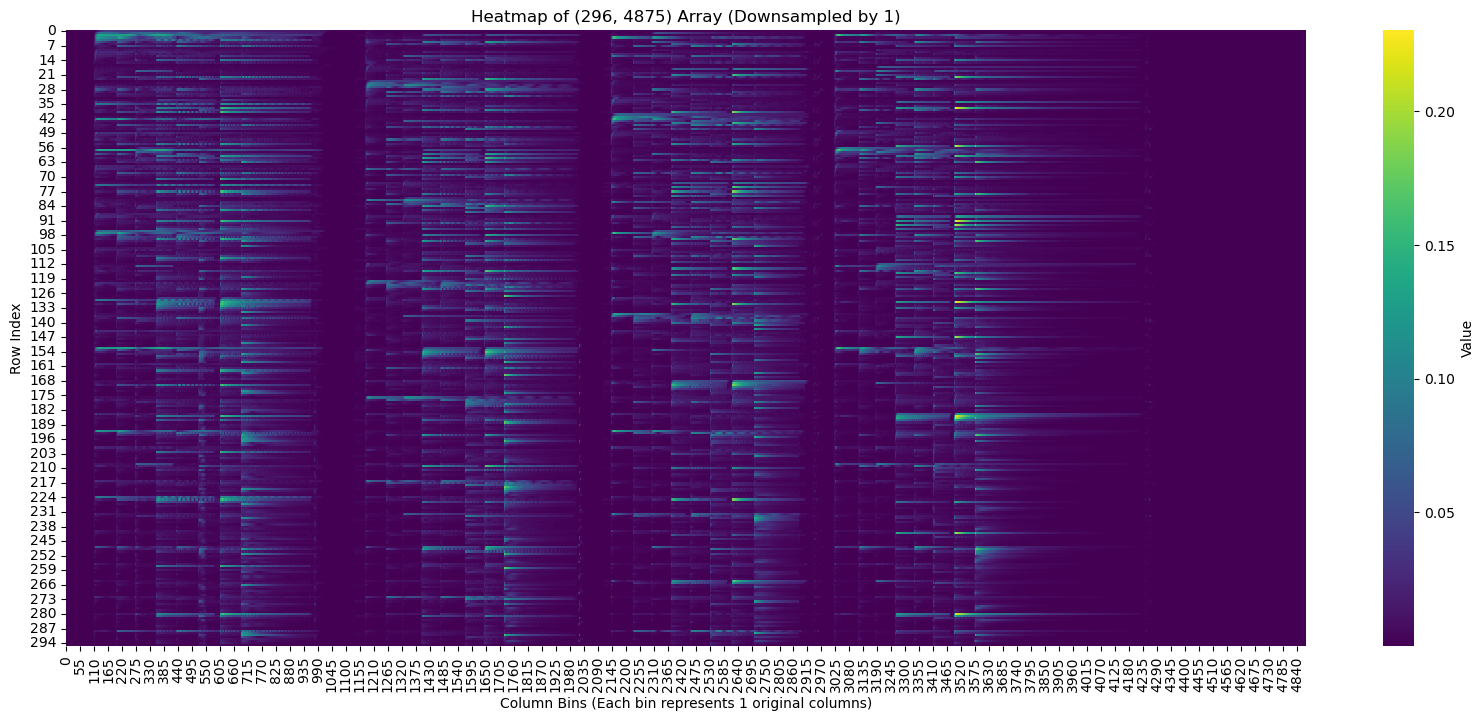

Heatmap displayed.


In [1]:
from scipy import io
from fretboardnonredundant import FretBoard
import numpy
import matplotlib.pyplot as plt
import wave
from common import plot_heatmap,reshape_to_nn_input
sampleRate,input_signal_test=io.wavfile.read('../../assets/testdata/E-G-A-B-chords.wav')
# sampleRate,input_signal_test=io.wavfile.read('../../assets/trainingdata/chords/session_original.wav')
print(sampleRate)
filter=FretBoard(20,sampleRate)
numfilters=filter.get_num_filters()
audio_test=input_signal_test#[:,1];

audiomin=numpy.min(audio_test)
audiomax=numpy.max(audio_test)

audio_test=numpy.multiply((audio_test-audiomin)/(audiomax-audiomin),2)-1
print(len(audio_test))
nFrames =input_signal_test.shape[0]
time=numpy.linspace(0,len(audio_test)/sampleRate,len(audio_test))

plt.plot(time, audio_test, label='Input')

filterbank_out_test=numpy.zeros((numfilters,len(audio_test)))

filter.process(audio_test,filterbank_out_test)

plot_heatmap(filterbank_out_test)

nn_input_test=reshape_to_nn_input(filterbank_out_test)

plot_heatmap(nn_input_test.swapaxes(0,1).max(axis=2),downsample_factor=1)

(4875, 296, 256)
(296, 256, 1)
test shape (4875, 296, 256)
Input sample shape (296, 256)
Input shape for model  (1, 296, 256, 1)
Building Model
Initial input shape: (1, 296, 512)
After first Conv2D: (1, 148, 64)
Extracting string from filters 0 to 20
String 0 section shape: (1, 20, 64)
String 0 after first Conv1D: (1, 20, 128)
Extracting string from filters 21 to 40
String 21 section shape: (1, 19, 64)
String 21 after first Conv1D: (1, 19, 128)
Extracting string from filters 41 to 60
String 41 section shape: (1, 19, 64)
String 41 after first Conv1D: (1, 19, 128)
Extracting string from filters 61 to 76
String 61 section shape: (1, 15, 64)
String 61 after first Conv1D: (1, 15, 128)
Extracting string from filters 77 to 96
String 77 section shape: (1, 19, 64)
String 77 after first Conv1D: (1, 19, 128)
Extracting string from filters 97 to 147
String 97 section shape: (1, 50, 64)
String 97 after first Conv1D: (1, 50, 128)
Loading weights
Predicting
predictions shape(129, 1)
(129, 256)
129
(1

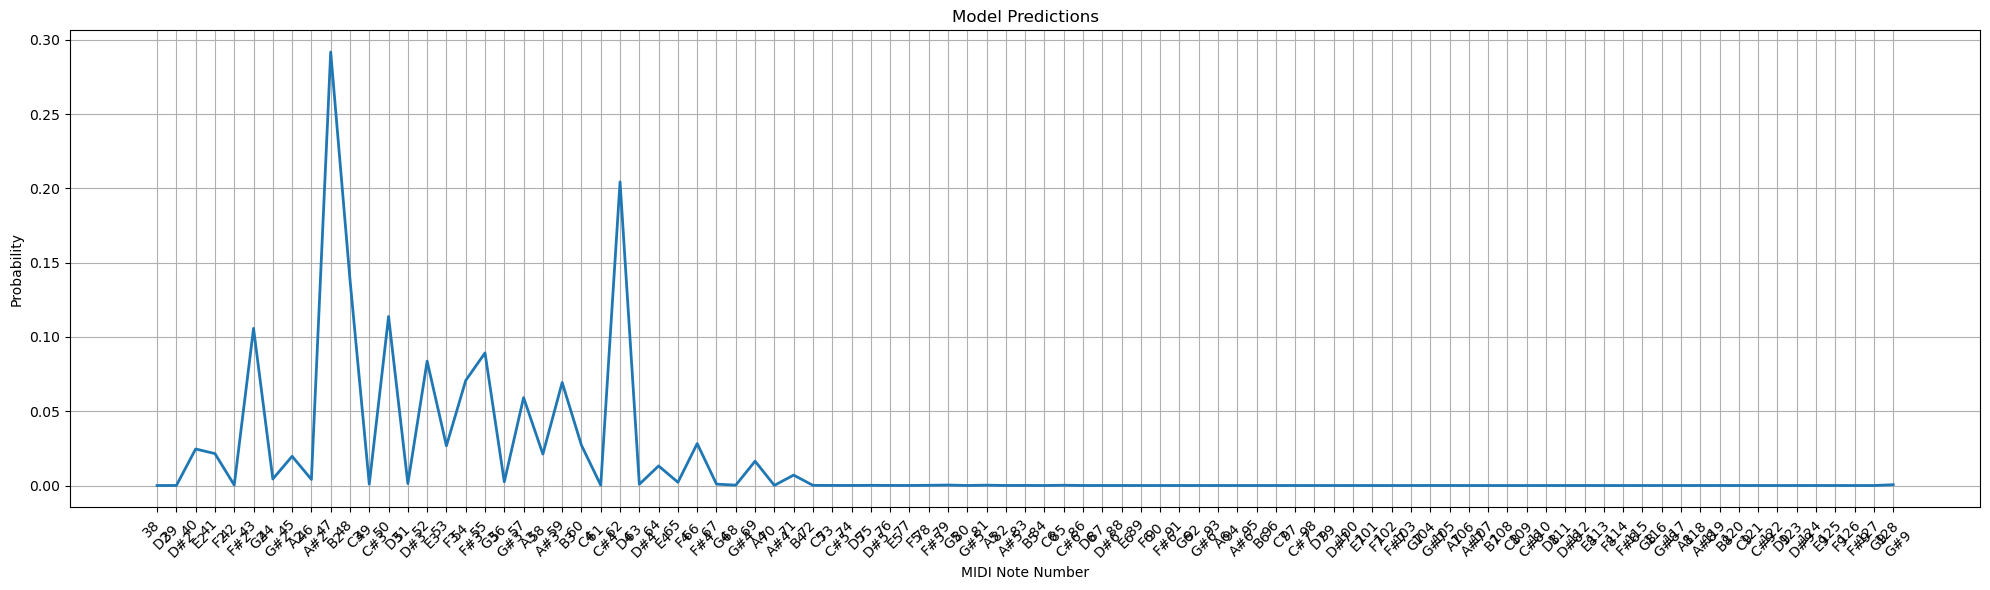

In [6]:
from common import INPUT_SHAPE,OUTPUT_DIM_NOTES,OUTPUT_DIM_ONSETS
import numpy as np
from model import build_1d_cnn_model
import tensorflow as tf
from tensorflow import keras
from keras.models import Model
print(nn_input_test.shape)
print(INPUT_SHAPE)




print("test shape",nn_input_test.shape)


# Reshape for the model: (batch_size, time_steps, num_filters, channels)
# For single inference, batch_size = 1, channels = 1
outsample=2035
outsample=220#370 # E
#outsample=1260 # G
#outsample=2390#2145 # A
# outsample=3135#3030 # B

print("Input sample shape",nn_input_test[int(outsample)].shape)
input_for_model = np.expand_dims(nn_input_test[int(outsample)], axis=0)  # Add batch dimension
input_for_model = np.expand_dims(input_for_model, axis=-1) # Add channel dimension


print("Input shape for model ",input_for_model.shape)
print("Building Model")
cnn_model=build_1d_cnn_model(1,INPUT_SHAPE,OUTPUT_DIM_NOTES)
expected_input_shape = input_for_model.shape[1:] 





print("Loading weights")
cnn_model.load_weights('guitarmidi.weights.h5')
cnn_model.build(input_shape=(None,) + expected_input_shape)

print("Predicting")
predictions_cnn = cnn_model.predict(input_for_model, verbose=0)

# all_predictions_cnn=np.zeros((nn_input_test.shape[0],OUTPUT_DIM_NOTES))
# for i in range(nn_input_test.shape[0]):
#     input_for_model=np.expand_dims(nn_input_test[i],axis=0)
#     input_for_model=np.expand_dims(input_for_model,axis=-1)
#     all_predictions_cnn[i]=cnn_model.predict(input_for_model,verbose=0)


# print("Model Summary")
# cnn_model.summary()
# print("Layer details:")
# # for layer in cnn_model.layers:
# #     print(layer.name, layer.output.shape, layer.input.shape)
# print("Building activation model")
# layer_outputs = [layer.output for layer in cnn_model.layers]

# activation_model=Model(inputs=cnn_model.layers[0].input, outputs=layer_outputs)
# layeractivations=activation_model.predict(input_for_model)



predictions_cnn=np.swapaxes(predictions_cnn,0,1)
print('predictions shape'+str(predictions_cnn.shape))
pred=np.repeat(predictions_cnn,256,axis=1)
print(pred.shape)
#plot_heatmap(pred)

# print(predictions_cnn)
xpred=range(1,len(predictions_cnn))
print(len(predictions_cnn))
print(predictions_cnn.shape)


def midi_to_note(midi_num):
    notes = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    note_name = notes[midi_num % 12]
    octave = (midi_num // 12) - 1
    return f"{note_name}{octave}"

# Create a wider figure
plt.figure(figsize=(20, 6))

# Plot with MIDI note numbers on x-axis
plt.plot(range(38,OUTPUT_DIM_NOTES), predictions_cnn[range(38,OUTPUT_DIM_NOTES)], linewidth=2)
plt.grid(True)
plt.xlabel('MIDI Note Number')
plt.ylabel('Probability')
plt.title('Model Predictions')

# Add x-ticks with both MIDI numbers and note names
x_ticks = range(38, OUTPUT_DIM_NOTES, 1)
x_labels = [f"{n}\n{midi_to_note(n)}" for n in x_ticks]
plt.xticks(x_ticks, x_labels, rotation=45)

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()


# # Create a wider figure
# plt.figure(figsize=(15, 5))

# # Plot with MIDI note numbers on x-axis
# plt.plot(range(38,OUTPUT_DIM_NOTES), predictions_cnn[range(38,OUTPUT_DIM_NOTES)], linewidth=2)
# plt.grid(True)
# plt.xlabel('MIDI Note Number')
# plt.ylabel('Probability')
# plt.title('Model Predictions')

# # Add x-ticks every 12 notes (one octave)
# plt.xticks(range(38, OUTPUT_DIM_NOTES, 1))

# # Adjust layout to prevent label cutoff
# plt.tight_layout()
# plt.show()

# plt.plot(nn_output[int(outsample/256)])

In [3]:
plot_heatmap(all_predictions_cnn.swapaxes(0,1),1)

NameError: name 'all_predictions_cnn' is not defined

In [ ]:
from datetime import datetime
import os
log_dir="logs/inference/"+datetime.now().strftime("%Y%m%d-%H%M%S")
file_writer=tf.summary.create_file_writer(log_dir)
with file_writer.as_default():
    for i,(activation,layer) in enumerate(zip(layeractivations,cnn_model.layers)):
        layer_name=layer.name
        tf.summary.histogram(f"{layer_name}/activation_distribution",activation,step=0)
        if 'conv' in layer_name.lower():# or 'pool' in layer_name.lower():
            # 
            print("Writing image for layer ",layer_name,activation.shape)
            image_tensor=activation#np.squeeze(activation,axis=0)
            for i in range(image_tensor.shape[3]):
                image_slice=image_tensor[:,:,:,i:i+1]
                slicename=layer_name+f"_filter_{i}"
                print("Image tensor,",slicename, " shape",image_slice.shape)
                
                tf.summary.image(f"{slicename}/featuremaps",image_slice,step=0,max_outputs=16)
            pass

file_writer.close()

# from model import build_cnn_model
# from common import INPUT_SHAPE, OUTPUT_DIM_NOTES
# import numpy as np
# from tensorboard_viz import visualize_model_architecture, visualize_layer_activations, visualize_predictions

# # Your existing code...
# cnn_model = build_cnn_model(INPUT_SHAPE, OUTPUT_DIM_NOTES)
# cnn_model.load_weights('checkpoints/guitarmidi_epoch13_valAcc0.5885.weights.h5')

# # Prepare your input
# input_for_model = np.expand_dims(nn_input_test[int(outsample)], axis=0)
# input_for_model = np.expand_dims(input_for_model, axis=-1)

# # Add TensorBoard visualization
# import datetime
# log_dir = "logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

# # Visualize architecture
# visualize_model_architecture()

# # Visualize activations
# visualize_layer_activations(cnn_model, input_for_model, log_dir)

# # Get predictions
# predictions_cnn = cnn_model.predict(input_for_model, verbose=0)

# # Visualize predictions
# visualize_predictions(predictions_cnn[0], log_dir=log_dir)

# # Launch TensorBoard
# print("Run: tensorboard --logdir=logs")


NameError: name 'layeractivations' is not defined

In [ ]:
test={0:82,1:87}

print(type(test))
print(test)
print(test.keys())

<class 'dict'>
{0: 82, 1: 87}
dict_keys([0, 1])
